In [1]:
import pandas as pd

数据来源文件读取

In [2]:
happiness = pd.read_csv("../data/happiness.csv")
income = pd.read_csv("../data/income.csv")
house = pd.read_csv("../data/house_price.csv")

happiness.head()

,city,happiness
0,Beijing,91.61
1,Shanghai,95.00
2,Tianjin,65.56
3,Chongqing,68.63
4,Guangzhou,82.16


查看数据规模

In [3]:
df = (
    happiness
    .merge(income, on="city")
    .merge(house, on="city")
)

print(f"数据集大小：{df.shape[0]} 行 × {df.shape[1]} 列")

df.head()

数据集大小：300 行 × 4 列


,city,happiness,income,house_price
0,Beijing,91.61,181438,48492
1,Shanghai,95.00,203863,61399
2,Tianjin,65.56,76008,11056
3,Chongqing,68.63,91580,11579
4,Guangzhou,82.16,138320,39415


显示数据类型

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         300 non-null    str    
 1   happiness    300 non-null    float64
 2   income       300 non-null    int64  
 3   house_price  300 non-null    int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 11.5 KB


数据描述统计

In [5]:
df.describe().round(2)

,happiness,income,house_price
count,300.00,300.00,300.00
mean,70.64,90738.31,14138.30
std,5.48,18966.63,12306.69
min,56.83,9800.00,7553.00
25%,67.10,81075.00,10859.50
50%,70.22,90711.00,12053.50
75%,72.79,97691.00,13562.50
max,95.00,203863.00,165000.00


缺失值检查

In [6]:
df = (
    happiness
    .merge(income, on="city")
    .merge(house, on="city")
)

print("Missing Values:")
print(df.isnull().sum())

df.head()

Missing Values:
city           0
happiness      0
income         0
house_price    0
dtype: int64


,city,happiness,income,house_price
0,Beijing,91.61,181438,48492
1,Shanghai,95.00,203863,61399
2,Tianjin,65.56,76008,11056
3,Chongqing,68.63,91580,11579
4,Guangzhou,82.16,138320,39415


数据重复性检查

In [7]:
duplicates = df["city"].duplicated().sum()

print(f"Duplicate cities: {duplicates}")

df.head()

Duplicate cities: 0


,city,happiness,income,house_price
0,Beijing,91.61,181438,48492
1,Shanghai,95.00,203863,61399
2,Tianjin,65.56,76008,11056
3,Chongqing,68.63,91580,11579
4,Guangzhou,82.16,138320,39415


数据表合并与城市对应省份的映射

In [8]:
city_map = {
    "Beijing": "北京市",
    "Shanghai": "上海市",
    "Tianjin": "天津市",
    "Chongqing": "重庆市",
    "Guangzhou": "广东省",
    "Shenzhen": "广东省",
    "Hangzhou": "浙江省",
    "Nanjing": "江苏省",
    "Suzhou": "江苏省",
    "Chengdu": "四川省",
    "Wuhan": "湖北省",
    "Xi'an": "陕西省",
    "Zhengzhou": "河南省",
    "Qingdao": "山东省",
    "Ningbo": "浙江省",
    "Xiamen": "福建省",
    "Fuzhou": "福建省",
    "Jinan": "山东省",
    "Changsha": "湖南省",
    "Hefei": "安徽省",
    "Kunming": "云南省",
    "Harbin": "黑龙江省",
    "Shenyang": "辽宁省",
    "Dalian": "辽宁省",
    "Changchun": "吉林省",
    "Nanchang": "江西省",
    "Guiyang": "贵州省",
    "Nanning": "广西壮族自治区",
    "Haikou": "海南省",
    "Lanzhou": "甘肃省",
    "Yinchuan": "宁夏回族自治区",
    "Xining": "青海省",
    "Urumqi": "新疆维吾尔自治区",
    "Hohhot": "内蒙古自治区",
    "Shijiazhuang": "河北省",
    "Taiyuan": "山西省",
    "Wuxi": "江苏省",
    "Foshan": "广东省",
    "Dongguan": "广东省",
    "Zhuhai": "广东省",
    "Zhongshan": "广东省",
    "Wenzhou": "浙江省",
    "Jiaxing": "浙江省",
    "Shaoxing": "浙江省",
    "Jinhua": "浙江省",
    "Taizhou": "浙江省",
    "Huzhou": "浙江省",
    "Lishui": "浙江省",
    "Quzhou": "浙江省",
    "Yantai": "山东省",
    "Weihai": "山东省",
    "Weifang": "山东省",
    "Linyi": "山东省",
    "Jining": "山东省",
    "Zibo": "山东省",
    "Dongying": "山东省",
    "Dezhou": "山东省",
    "Binzhou": "山东省",
    "Liaocheng": "山东省",
    "Tai'an": "山东省",
    "Rizhao": "山东省",
    "Luoyang": "河南省",
    "Kaifeng": "河南省",
    "Anyang": "河南省",
    "Xinxiang": "河南省",
    "Xuchang": "河南省",
    "Pingdingshan": "河南省",
    "Nanyang": "河南省",
    "Shangqiu": "河南省",
    "Zhoukou": "河南省",
    "Zhumadian": "河南省",
    "Xinyang": "河南省",
    "Yichang": "湖北省",
    "Xiangyang": "湖北省",
    "Jingzhou": "湖北省",
    "Huangshi": "湖北省",
    "Ezhou": "湖北省",
    "Xiaogan": "湖北省",
    "Huanggang": "湖北省",
    "Xianning": "湖北省",
    "Changde": "湖南省",
    "Yueyang": "湖南省",
    "Hengyang": "湖南省",
    "Zhuzhou": "湖南省",
    "Xiangtan": "湖南省",
    "Yiyang": "湖南省",
    "Loudi": "湖南省",
    "Huaihua": "湖南省",
    "Yongzhou": "湖南省",
    "Chenzhou": "湖南省",
    "Shaoyang": "湖南省",
    "Yibin": "四川省",
    "Mianyang": "四川省",
    "Deyang": "四川省",
    "Leshan": "四川省",
    "Luzhou": "四川省",
    "Nanchong": "四川省",
    "Neijiang": "四川省",
    "Zigong": "四川省",
    "Meishan": "四川省",
    "Guang'an": "四川省",
    "Dazhou": "四川省",
    "Bazhong": "四川省",
    "Ya'an": "四川省",
    "Zunyi": "贵州省",
    "Liupanshui": "贵州省",
    "Anshun": "贵州省",
    "Bijie": "贵州省",
    "Tongren": "贵州省",
    "Guilin": "广西壮族自治区",
    "Liuzhou": "广西壮族自治区",
    "Beihai": "广西壮族自治区",
    "Qinzhou": "广西壮族自治区",
    "Yulin": "广西壮族自治区",
    "Baise": "广西壮族自治区",
    "Hezhou": "广西壮族自治区",
    "Hechi": "广西壮族自治区",
    "Wuzhou": "广西壮族自治区",
    "Sanya": "海南省",
    "Danzhou": "海南省",
    "Tangshan": "河北省",
    "Qinhuangdao": "河北省",
    "Baoding": "河北省",
    "Langfang": "河北省",
    "Cangzhou": "河北省",
    "Handan": "河北省",
    "Xingtai": "河北省",
    "Hengshui": "河北省",
    "Zhangjiakou": "河北省",
    "Chengde": "河北省",
    "Tibet": "西藏自治区",
    "Hong Kong": "香港特别行政区",
    "Macau": "澳门特别行政区",
    "Taiwan": "台湾省",
}

df = happiness.merge(income, on="city").merge(house, on="city")  # 三表合并
df['province'] = df['city'].map(city_map)  # 使用字典映射
print("映射后示例：\n", df[['city','province']].drop_duplicates().head(5), sep="")
print("\n映射后缺失值检查：", df['province'].isnull().sum())


映射后示例：
        city province
0    Beijing      北京市
1   Shanghai      上海市
2    Tianjin      天津市
3  Chongqing      重庆市
4  Guangzhou      广东省

映射后缺失值检查： 166


性价比指标计算和各省市数据平均值的聚合与重命名

In [9]:
import numpy as np

# 计算性价比指标
df['value_index'] = df['income'] / df['house_price']

# 按省份聚合平均值
province_summary = df.groupby('province', as_index=False).agg({
    'happiness': 'mean',
    'income': 'mean',
    'house_price': 'mean',
    'value_index': 'mean'
})
# 重命名列为平均值
province_summary = province_summary.rename(columns={
    'happiness': 'avg_happiness',
    'income': 'avg_income',
    'house_price': 'avg_house_price',
    'value_index': 'avg_value_index'
})
print("\n省级聚合样例：\n", province_summary.head(5), sep="")


省级聚合样例：
  province  avg_happiness  avg_income  avg_house_price  avg_value_index
0      上海市          95.00    203863.0          61399.0         3.320298
1      云南省          68.94    101918.0          11313.0         9.008928
2   内蒙古自治区          67.12    105976.0          13347.0         7.940061
3      北京市          91.61    181438.0          48492.0         3.741607
4      台湾省          81.80     18500.0          42000.0         0.440476


住房可负担性指数排名前20的城市的数据显示

In [10]:
import pandas as pd
# 计算价值指数
df["value_index"] = (df["income"] / df["house_price"]).round(2)
# 取 Top20
top20 = (
    df.sort_values("value_index", ascending=False)
      .head(20)
      .reset_index(drop=True)
)

top20

,city,happiness,income,house_price,province,value_index
0,City112,70.49,104552,7553,NaN,13.84
1,City54,69.04,103668,7969,NaN,13.01
2,City84,70.60,103389,8110,NaN,12.75
3,City87,68.94,106003,9179,NaN,11.55
4,City125,64.25,108375,9559,NaN,11.34
5,City6,64.37,100401,8917,NaN,11.26
6,City154,70.81,98416,8912,NaN,11.04
7,City158,63.66,97636,8885,NaN,10.99
8,City140,66.89,120112,11054,NaN,10.87
9,City50,75.60,88638,8228,NaN,10.77


全国300个主要城市的住房可负担性指数的柱状图分布分析

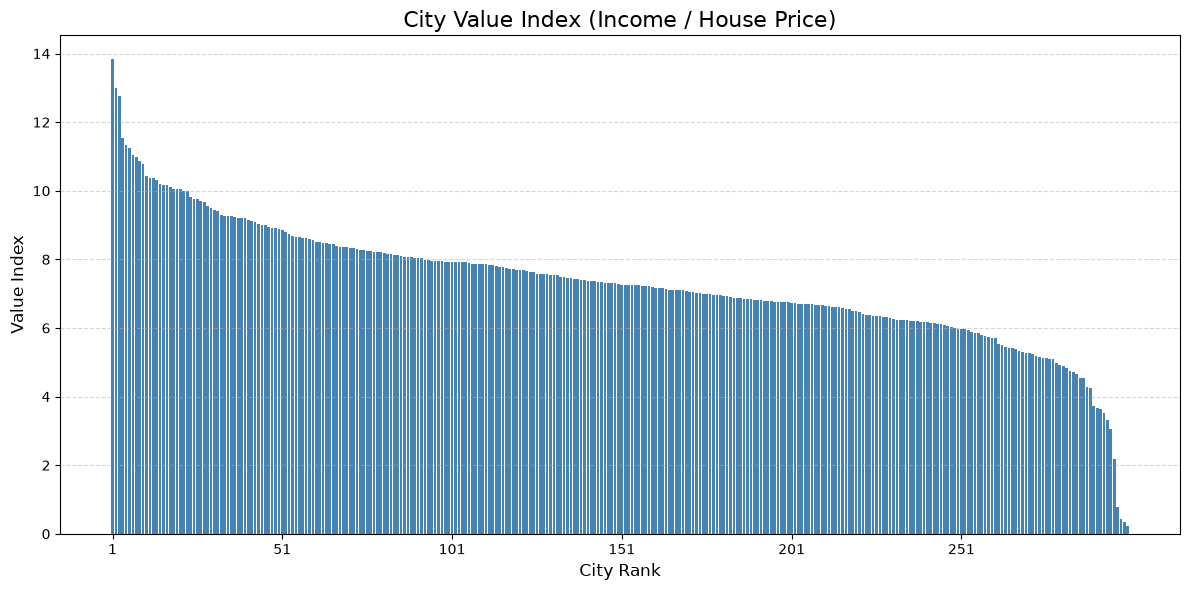

In [11]:
import matplotlib.pyplot as plt
import numpy as np
#按价值指数降序排序
top = df.sort_values("value_index", ascending=False).reset_index(drop=True)
#创建画布
fig, ax = plt.subplots(figsize=(12, 6))
#绘制柱状图
ax.bar(range(len(top)), top["value_index"], color="steelblue")
#每50个城市显示一个排名
step = 50
ticks = np.arange(0, len(top), step)

ax.set_xticks(ticks)
ax.set_xticklabels([str(i + 1) for i in ticks])
#设置标题和坐标轴标签
ax.set_title("City Value Index (Income / House Price)", fontsize=16)
ax.set_xlabel("City Rank", fontsize=12)
ax.set_ylabel("Value Index", fontsize=12)
#添加横向网格线
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

全国300个主要城市的幸福度的条形图分布分析

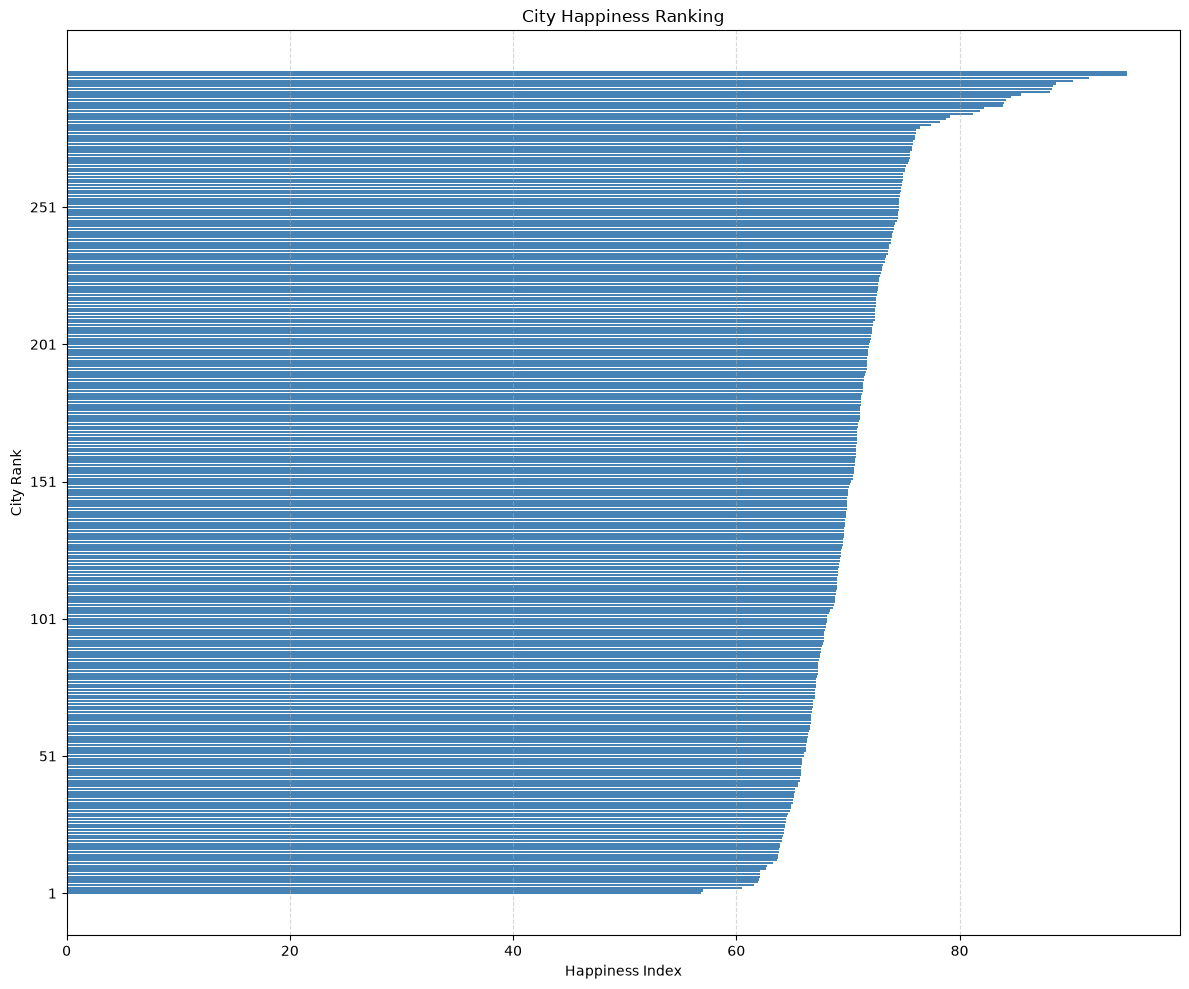

In [12]:
import matplotlib.pyplot as plt
#按幸福度排序
df_sorted = df.sort_values("happiness").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(range(len(df_sorted)), df_sorted["happiness"], color="steelblue")
#每50个城市显示一个刻度
step = 50
ticks = list(range(0, len(df_sorted), step))
ax.set_yticks(ticks)
ax.set_yticklabels([str(i + 1) for i in ticks])

ax.set_xlabel("Happiness Index")
ax.set_ylabel("City Rank")
ax.set_title("City Happiness Ranking")
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

全国300个主要城市的收入与幸福度之间的散点图分布分析

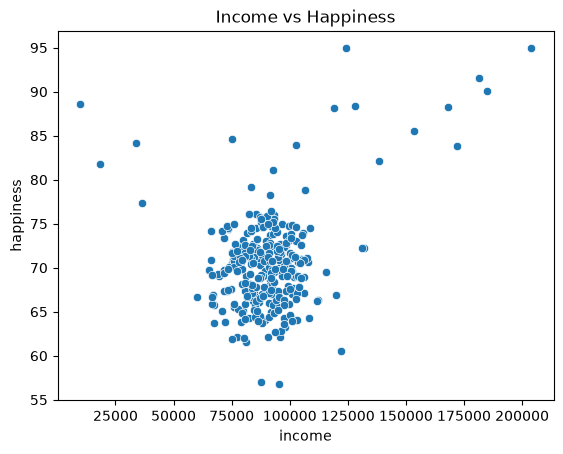

In [13]:
import seaborn as sns

sns.scatterplot(data=df, x="income", y="happiness")
plt.title("Income vs Happiness")
plt.show()

全国300个主要城市的房价与幸福度之间的散点图分布分析

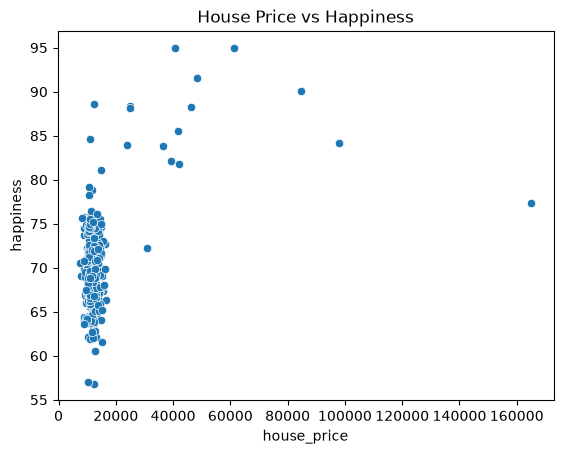

In [14]:
sns.scatterplot(data=df, x="house_price", y="happiness")
plt.title("House Price vs Happiness")
plt.show()

中国城市生活成本与幸福感分析的可视化地图

In [15]:
from pyecharts.charts import Map
from pyecharts import options as opts

# 按省份计算平均幸福感
prov_data = df.groupby('province')['happiness'].mean().reset_index()
# 生成地图数据项列表
map_data = list(zip(prov_data['province'], prov_data['happiness']))

# 创建 Map 实例并添加数据
m = Map()
m.add("幸福感指数", map_data, "china")

# 配置全局选项：标题和视觉映射组件（分段）
m.set_global_opts(
    title_opts=opts.TitleOpts(title="中国各省份平均幸福感"),
    visualmap_opts=opts.VisualMapOpts(
        min_=prov_data['happiness'].min(),
        max_=prov_data['happiness'].max(),
        is_piecewise=True,  # 分段式视觉映射
        pieces=[
            {"min": 90, "label": "极高"},
            {"min": 80, "max": 90, "label": "较高"},
            {"min": 70, "max": 80, "label": "中等"},
            {"max": 70, "label": "较低"},
        ]
    )
)
# 不显示地图上每个省的标签
m.set_series_opts(label_opts=opts.LabelOpts(is_show=False))
# 渲染HTML文件
m.render("happiness_map.html")


'c:\\Users\\86132\\Desktop\\中国城市生活成本与幸福感分析可视化\\notebooks\\happiness_map.html'